# Notebook 03: Price Extraction and Event Windows

## Academic Introduction

This notebook constructs the historical price layer for the auditor-switch event study. Event-study analysis requires prices before and after the auditor-switch event so later notebooks can calculate stock returns, market returns, and market-adjusted returns.

The project uses trading days rather than calendar days. If an event date falls on a non-trading day, the event trading date is defined as the nearest available trading day on or after the event date. The event window prepared here is `t-5`, event trading date, and `t+5`, based on actual available trading dates.

TA-125 is used as the benchmark market index. This notebook does not compute final abnormal returns, run statistical tests, build the Streamlit dashboard, or make causal claims. It only prepares event-window price observations and documents missing-data limitations. Missing prices, unmapped tickers, future events, and insufficient trading windows are retained as row-level status flags rather than silently dropped.

In [16]:
import sys
!{sys.executable} -m pip install yfinance


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Guy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
import yfinance as yf

test_tickers = ["^TA125.TA", "LUMI.TA", "TEVA.TA", "MTRX.TA"]

for ticker in test_tickers:
    print("=" * 80)
    print("Testing:", ticker)
    try:
        df = yf.download(
            ticker,
            start="2024-01-01",
            end="2024-02-01",
            progress=False,
            auto_adjust=False
        )
        print("shape:", df.shape)
        print(df.tail())
    except Exception as e:
        print("ERROR:", repr(e))

Testing: ^TA125.TA
shape: (19, 6)
Price         Adj Close        Close         High          Low         Open  \
Ticker        ^TA125.TA    ^TA125.TA    ^TA125.TA    ^TA125.TA    ^TA125.TA   
2024-01-24  1867.890015  1867.890015  1877.189941  1857.510010  1862.089966   
2024-01-25  1861.569946  1861.569946  1865.800049  1851.400024  1859.329956   
2024-01-29  1889.640015  1889.640015  1894.500000  1864.900024  1873.969971   
2024-01-30  1870.750000  1870.750000  1889.739990  1870.750000  1889.739990   
2024-01-31  1861.920044  1861.920044  1879.739990  1861.920044  1871.089966   

Price         Volume  
Ticker     ^TA125.TA  
2024-01-24  47595900  
2024-01-25  87332400  
2024-01-29  45676500  
2024-01-30         0  
2024-01-31  65353000  
Testing: LUMI.TA
shape: (19, 6)
Price         Adj Close   Close    High     Low    Open   Volume
Ticker          LUMI.TA LUMI.TA LUMI.TA LUMI.TA LUMI.TA  LUMI.TA
2024-01-24  2745.004395  2747.0  2762.0  2723.0  2735.0  2867963
2024-01-25  2698.039062 

## 1. Imports and Configuration

`yfinance` is the primary automatic price source. If it is not installed, the notebook still runs and creates the required output files with clear status values. To enable automatic price extraction, install it with:

```bash
pip install yfinance
```

In [18]:
import json
import time
import traceback
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
    YFINANCE_IMPORT_ERROR = ""
except Exception as exc:
    yf = None
    YFINANCE_AVAILABLE = False
    YFINANCE_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
    warnings.warn(
        "yfinance is required for automatic price extraction. "
        "Install it with: pip install yfinance"
    )

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception:
    plt = None
    MATPLOTLIB_AVAILABLE = False

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
DATA_INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
DATA_OUTPUT_DIR = PROJECT_ROOT / "data" / "output"
PRICE_CACHE_DIR = PROJECT_ROOT / "data" / "cache" / "prices"

PRICE_SOURCE = "yfinance"
MARKET_INDEX_TICKER = "^TA125.TA"
EVENT_WINDOW_TRADING_DAYS = 5
PRICE_HISTORY_BUFFER_DAYS = 45

for folder in [DATA_INTERIM_DIR, DATA_OUTPUT_DIR, PRICE_CACHE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

EXTRACTION_RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat()

print(f"Project root: {PROJECT_ROOT}")
print(f"yfinance available: {YFINANCE_AVAILABLE}")
if not YFINANCE_AVAILABLE:
    print("Automatic price extraction is disabled until yfinance is installed: pip install yfinance")

Project root: C:\Users\Guy\Desktop\Tene
yfinance available: True


## 2. Load Event Dataset

Notebook 03 depends on the event-level identifier dataset produced by Notebook 02. If the file is missing, Notebook 02 must be rerun before continuing.

In [19]:
events_with_identifiers_path = DATA_INTERIM_DIR / "clean_events_with_identifiers_v01.csv"
if not events_with_identifiers_path.exists():
    raise FileNotFoundError("Notebook 02 must be run before Notebook 03.")

events_df = pd.read_csv(events_with_identifiers_path, encoding="utf-8-sig")

for date_column in ["event_date", "auditor_switch_date", "report_publication_date"]:
    if date_column in events_df.columns:
        events_df[date_column] = pd.to_datetime(events_df[date_column], errors="coerce")

print(f"Total event rows: {len(events_df)}")
print(f"Unique companies: {events_df['company_name'].nunique(dropna=True)}")
display(events_df["mapping_status"].value_counts(dropna=False).rename_axis("mapping_status").reset_index(name="event_count"))
display(events_df["price_extraction_eligibility"].value_counts(dropna=False).rename_axis("price_extraction_eligibility").reset_index(name="event_count"))
print(f"Future events: {int(events_df.get('event_is_future', pd.Series(False, index=events_df.index)).fillna(False).astype(bool).sum())}")
print(f"Rows with yahoo_ticker: {int(events_df['yahoo_ticker'].notna().sum()) if 'yahoo_ticker' in events_df.columns else 0}")
print(f"Rows missing yahoo_ticker: {int(events_df['yahoo_ticker'].isna().sum()) if 'yahoo_ticker' in events_df.columns else len(events_df)}")
events_df.head()

Total event rows: 50
Unique companies: 49


,mapping_status,event_count
0,MAPPED_MANUALLY,49
1,PENDING_MANUAL_REVIEW,1


,price_extraction_eligibility,event_count
0,ELIGIBLE_FOR_PRICE_EXTRACTION,48
1,FUTURE_EVENT_DATE,2


Future events: 2
Rows with yahoo_ticker: 45
Rows missing yahoo_ticker: 5


,company_name,auditor_switch_date_raw,auditor_switch_date,auditor_switch_date_status,report_publication_date_raw,report_publication_date,report_publication_date_status,event_date_basis,event_date_raw,event_date,...,raw__סך הנכסים,raw__הון עצמי,raw__רווח,yahoo_ticker,google_finance_symbol,tase_security_id,isin,mapping_status,mapping_confidence,needs_manual_review
0,אבו מגורים,16/11/2025,2025-11-16,OK,19/3/2026,2026-03-19,OK,auditor_switch_date,16/11/2025,2025-11-16,...,7.745000e+08,2.406000e+08,4540000.0,ABOU.TA,TLV:ABOU,1175819.0,NaN,MAPPED_MANUALLY,HIGH,False
1,גלובל פיי-ש,19/02/2025,2025-02-19,OK,31/3/2025,2025-03-31,OK,auditor_switch_date,19/02/2025,2025-02-19,...,1.800000e+07,1.110000e+07,510000.0,GKL.TA,TLV:GKL,1141316.0,NaN,MAPPED_MANUALLY,HIGH,False
2,"אמיליה פיתוח )מ.עו.פ.( בע""מ",17/02/2026,2026-02-17,OK,30/3/2026,2026-03-30,OK,auditor_switch_date,17/02/2026,2026-02-17,...,4.340000e+09,1.570000e+09,151500000.0,EMDV.TA,TLV:EMDV,NaN,NaN,MAPPED_MANUALLY,HIGH,False
3,"שדה נדל""ן",2024-05-03 00:00:00,2024-05-03,OK,31/3/2024,2024-03-31,OK,auditor_switch_date,2024-05-03 00:00:00,2024-05-03,...,1.530000e+07,1.390000e+07,-14400000.0,SADE.TA,TLV:SADE,NaN,IL0003410169,MAPPED_MANUALLY,HIGH,False
4,ספידווליו,24/08/2025,2025-08-24,OK,25/03/2026,2026-03-25,OK,auditor_switch_date,24/08/2025,2025-08-24,...,1.246000e+08,5.180000e+07,4860000.0,SPDV.TA,TLV:SPDV,1178284.0,NaN,MAPPED_MANUALLY,HIGH,False


## 3. Price Extraction Status Design

Each row starts from eligibility checks and then receives a final `price_status`. A row may be structurally ready at the beginning but later become a specific missing-data status if ticker validation, stock prices, market prices, or event-window trading days are unavailable.

In [20]:
PRICE_STATUS_VALUES = [
    "READY_FOR_PRICE_EXTRACTION",
    "FUTURE_EVENT_DATE",
    "MISSING_TICKER",
    "INVALID_EVENT_DATE",
    "TICKER_VALIDATION_FAILED",
    "MISSING_STOCK_PRICE_DATA",
    "MISSING_MARKET_PRICE_DATA",
    "NOT_ENOUGH_TRADING_DAYS_BEFORE",
    "NOT_ENOUGH_TRADING_DAYS_AFTER",
    "EVENT_DATE_OUT_OF_PRICE_RANGE",
    "OK",
    "UNKNOWN_ERROR",
]

MARKET_PRICE_STATUS_VALUES = [
    "OK",
    "MISSING_MARKET_PRICE_DATA",
    "MARKET_DATE_SUBSTITUTED",
    "EVENT_DATE_OUT_OF_PRICE_RANGE",
    "YFINANCE_NOT_AVAILABLE",
]

PRICE_STATUS_VALUES

['READY_FOR_PRICE_EXTRACTION',
 'FUTURE_EVENT_DATE',
 'MISSING_TICKER',
 'INVALID_EVENT_DATE',
 'TICKER_VALIDATION_FAILED',
 'MISSING_STOCK_PRICE_DATA',
 'MISSING_MARKET_PRICE_DATA',
 'NOT_ENOUGH_TRADING_DAYS_BEFORE',
 'NOT_ENOUGH_TRADING_DAYS_AFTER',
 'EVENT_DATE_OUT_OF_PRICE_RANGE',
 'OK',
 'UNKNOWN_ERROR']

## 4. Helper Functions

The helper functions below handle date parsing, ticker normalization, cache paths, cached price loading, yfinance downloads, series validation, trading-day event-window selection, and market-price date matching.

In [21]:
cache_files_created_or_used = set()


def safe_parse_date(value):
    if pd.isna(value):
        return pd.NaT
    parsed = pd.to_datetime(value, errors="coerce")
    if pd.isna(parsed):
        return pd.NaT
    return pd.Timestamp(parsed).normalize()


def normalize_ticker(ticker):
    if pd.isna(ticker):
        return None
    text = str(ticker).strip()
    if text == "" or text.lower() in {"nan", "none", "null"}:
        return None
    return text


def filesystem_safe_ticker(ticker):
    return "".join(char if char.isalnum() else "_" for char in str(ticker)).strip("_")


def get_cache_path(ticker, start_date, end_date):
    start = pd.Timestamp(start_date).strftime("%Y%m%d")
    end = pd.Timestamp(end_date).strftime("%Y%m%d")
    safe_ticker = filesystem_safe_ticker(ticker)
    return PRICE_CACHE_DIR / f"{safe_ticker}_{start}_{end}_{PRICE_SOURCE}.csv"


def load_cached_price_data(ticker, start_date, end_date):
    cache_path = get_cache_path(ticker, start_date, end_date)
    if not cache_path.exists():
        return None
    try:
        df = pd.read_csv(cache_path, encoding="utf-8-sig")
        if "Date" in df.columns:
            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        cache_files_created_or_used.add(str(cache_path.relative_to(PROJECT_ROOT)))
        return df
    except Exception as exc:
        warnings.warn(f"Could not read cache file {cache_path.name}: {exc}")
        return None


def save_cached_price_data(ticker, start_date, end_date, df):
    cache_path = get_cache_path(ticker, start_date, end_date)
    df.to_csv(cache_path, index=False, encoding="utf-8-sig")
    cache_files_created_or_used.add(str(cache_path.relative_to(PROJECT_ROOT)))
    return cache_path


def standardize_price_columns(raw_df, ticker):
    if raw_df is None or raw_df.empty:
        return pd.DataFrame(columns=["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume", "ticker", "price_source"])

    df = raw_df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            "_".join(str(part) for part in col if str(part) != "")
            for col in df.columns.to_flat_index()
        ]

    if "Date" not in df.columns:
        df = df.reset_index()

    rename_map = {}
    for column in df.columns:
        normalized = str(column).replace(" ", "_")
        if normalized.lower().startswith("date"):
            rename_map[column] = "Date"
        elif normalized.lower().startswith("open"):
            rename_map[column] = "Open"
        elif normalized.lower().startswith("high"):
            rename_map[column] = "High"
        elif normalized.lower().startswith("low"):
            rename_map[column] = "Low"
        elif normalized.lower().startswith("close"):
            rename_map[column] = "Close"
        elif normalized.lower().startswith("adj_close"):
            rename_map[column] = "Adj_Close"
        elif normalized.lower().startswith("volume"):
            rename_map[column] = "Volume"

    df = df.rename(columns=rename_map)
    for column in ["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume"]:
        if column not in df.columns:
            df[column] = np.nan

    df = df[["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume"]].copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce").dt.normalize()
    for column in ["Open", "High", "Low", "Close", "Adj_Close", "Volume"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").drop_duplicates("Date", keep="last").reset_index(drop=True)
    df["ticker"] = ticker
    df["price_source"] = PRICE_SOURCE
    return df


def fetch_price_data_yfinance(ticker, start_date, end_date):
    if not YFINANCE_AVAILABLE:
        raise ImportError("yfinance is required for automatic price extraction. Install it with: pip install yfinance")

    raw = yf.download(
        ticker,
        start=pd.Timestamp(start_date).strftime("%Y-%m-%d"),
        end=(pd.Timestamp(end_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=False,
        progress=False,
        threads=False,
    )
    return standardize_price_columns(raw, ticker)


def get_price_data(ticker, start_date, end_date):
    cached = load_cached_price_data(ticker, start_date, end_date)
    if cached is not None and not cached.empty:
        return cached
    fetched = fetch_price_data_yfinance(ticker, start_date, end_date)
    if not fetched.empty:
        save_cached_price_data(ticker, start_date, end_date, fetched)
    return fetched


def validate_price_series(df):
    if df is None or df.empty:
        return {
            "has_data": False,
            "min_date": None,
            "max_date": None,
            "number_of_observations": 0,
            "has_close_column": False,
            "validation_message": "NO_DATA_RETURNED",
        }
    has_close = "Close" in df.columns and df["Close"].notna().any()
    return {
        "has_data": bool(len(df) > 0),
        "min_date": None if df["Date"].dropna().empty else str(df["Date"].min().date()),
        "max_date": None if df["Date"].dropna().empty else str(df["Date"].max().date()),
        "number_of_observations": int(len(df)),
        "has_close_column": bool(has_close),
        "validation_message": "OK" if has_close else "MISSING_CLOSE_COLUMN",
    }


def find_event_window_dates(price_df, event_date, window=5):
    empty_result = {
        "t_minus_5_date": pd.NaT,
        "event_trading_date": pd.NaT,
        "t_plus_5_date": pd.NaT,
        "stock_price_t_minus_5": np.nan,
        "stock_price_event": np.nan,
        "stock_price_t_plus_5": np.nan,
        "status": "MISSING_STOCK_PRICE_DATA",
        "notes": "",
    }
    if price_df is None or price_df.empty or "Close" not in price_df.columns:
        empty_result["notes"] = "No stock price data available."
        return empty_result
    if pd.isna(event_date):
        empty_result["status"] = "INVALID_EVENT_DATE"
        empty_result["notes"] = "Invalid event date."
        return empty_result

    df = price_df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
    if df.empty:
        empty_result["notes"] = "No non-missing close prices available."
        return empty_result

    event_date = pd.Timestamp(event_date).normalize()
    candidate_positions = df.index[df["Date"] >= event_date].tolist()
    if not candidate_positions:
        empty_result["status"] = "EVENT_DATE_OUT_OF_PRICE_RANGE"
        empty_result["notes"] = "No trading date on or after event date."
        return empty_result

    event_pos = candidate_positions[0]
    if event_pos < window:
        empty_result["status"] = "NOT_ENOUGH_TRADING_DAYS_BEFORE"
        empty_result["notes"] = f"Need {window} trading days before event trading date."
        empty_result["event_trading_date"] = df.loc[event_pos, "Date"]
        empty_result["stock_price_event"] = df.loc[event_pos, "Close"]
        return empty_result
    if event_pos + window >= len(df):
        empty_result["status"] = "NOT_ENOUGH_TRADING_DAYS_AFTER"
        empty_result["notes"] = f"Need {window} trading days after event trading date."
        empty_result["event_trading_date"] = df.loc[event_pos, "Date"]
        empty_result["stock_price_event"] = df.loc[event_pos, "Close"]
        return empty_result

    minus_pos = event_pos - window
    plus_pos = event_pos + window
    return {
        "t_minus_5_date": df.loc[minus_pos, "Date"],
        "event_trading_date": df.loc[event_pos, "Date"],
        "t_plus_5_date": df.loc[plus_pos, "Date"],
        "stock_price_t_minus_5": df.loc[minus_pos, "Close"],
        "stock_price_event": df.loc[event_pos, "Close"],
        "stock_price_t_plus_5": df.loc[plus_pos, "Close"],
        "status": "OK",
        "notes": "",
    }


def get_price_on_or_nearest_after(price_df, target_date):
    if price_df is None or price_df.empty or pd.isna(target_date):
        return np.nan, pd.NaT, "MISSING_MARKET_PRICE_DATA", "No market price data or target date."
    df = price_df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
    target_date = pd.Timestamp(target_date).normalize()
    exact = df.loc[df["Date"] == target_date]
    if not exact.empty:
        return exact.iloc[0]["Close"], exact.iloc[0]["Date"], "OK", ""
    after = df.loc[df["Date"] >= target_date]
    if after.empty:
        return np.nan, pd.NaT, "EVENT_DATE_OUT_OF_PRICE_RANGE", "No market date on or after target date."
    used = after.iloc[0]
    return used["Close"], used["Date"], "MARKET_DATE_SUBSTITUTED", f"Used nearest market date on or after {target_date.date()}."

## 5. Date Ranges for Fetching

Each non-future event uses a calendar buffer around the event date. Future events, missing tickers, and invalid event dates are flagged before any price fetch is attempted.

In [22]:
working_events_df = events_df.copy()
working_events_df["event_id"] = np.arange(1, len(working_events_df) + 1)
working_events_df["event_date"] = working_events_df["event_date"].apply(safe_parse_date)
working_events_df["normalized_yahoo_ticker"] = working_events_df.get("yahoo_ticker", pd.Series(index=working_events_df.index, dtype=object)).apply(normalize_ticker)
working_events_df["event_is_future"] = working_events_df.get("event_is_future", False).fillna(False).astype(bool)

working_events_df["fetch_start_date"] = working_events_df["event_date"] - pd.to_timedelta(PRICE_HISTORY_BUFFER_DAYS, unit="D")
working_events_df["fetch_end_date"] = working_events_df["event_date"] + pd.to_timedelta(PRICE_HISTORY_BUFFER_DAYS, unit="D")

working_events_df[[
    "event_id",
    "company_name",
    "event_date",
    "event_is_future",
    "price_extraction_eligibility",
    "normalized_yahoo_ticker",
    "fetch_start_date",
    "fetch_end_date",
]].head(10)

,event_id,company_name,event_date,event_is_future,price_extraction_eligibility,normalized_yahoo_ticker,fetch_start_date,fetch_end_date
0,1,אבו מגורים,2025-11-16,False,ELIGIBLE_FOR_PRICE_EXTRACTION,ABOU.TA,2025-10-02,2025-12-31
1,2,גלובל פיי-ש,2025-02-19,False,ELIGIBLE_FOR_PRICE_EXTRACTION,GKL.TA,2025-01-05,2025-04-05
2,3,"אמיליה פיתוח )מ.עו.פ.( בע""מ",2026-02-17,False,ELIGIBLE_FOR_PRICE_EXTRACTION,EMDV.TA,2026-01-03,2026-04-03
3,4,"שדה נדל""ן",2024-05-03,False,ELIGIBLE_FOR_PRICE_EXTRACTION,SADE.TA,2024-03-19,2024-06-17
4,5,ספידווליו,2025-08-24,False,ELIGIBLE_FOR_PRICE_EXTRACTION,SPDV.TA,2025-07-10,2025-10-08
5,6,הום ביוגז,2024-07-17,False,ELIGIBLE_FOR_PRICE_EXTRACTION,HMGS.TA,2024-06-02,2024-08-31
6,7,טוגדר,2025-07-28,False,ELIGIBLE_FOR_PRICE_EXTRACTION,TGTR.TA,2025-06-13,2025-09-11
7,8,אספן גרופ,2026-05-24,False,ELIGIBLE_FOR_PRICE_EXTRACTION,ASGR.TA,2026-04-09,2026-07-08
8,9,ג׳נסל בע״מ,2026-07-05,True,FUTURE_EVENT_DATE,GNCL.TA,2026-05-21,2026-08-19
9,10,נופר אנרג׳י,2026-07-05,True,FUTURE_EVENT_DATE,NOFR.TA,2026-05-21,2026-08-19


## 6. Validate Unique Securities First

Unique Yahoo tickers are validated before row-level event-window processing. This avoids repeatedly fetching the same ticker for each event and creates a reusable security-level audit table.

In [23]:
security_validation_records = []
stock_price_data_by_ticker = {}
error_records = []

unique_tickers = sorted([ticker for ticker in working_events_df["normalized_yahoo_ticker"].dropna().unique()])

for ticker in unique_tickers:
    ticker_events = working_events_df.loc[working_events_df["normalized_yahoo_ticker"] == ticker].copy()
    non_future_valid_events = ticker_events.loc[
        (~ticker_events["event_is_future"]) & ticker_events["event_date"].notna()
    ]
    record = {
        "yahoo_ticker": ticker,
        "number_of_events": int(len(ticker_events)),
        "min_event_date": None if ticker_events["event_date"].dropna().empty else str(ticker_events["event_date"].min().date()),
        "max_event_date": None if ticker_events["event_date"].dropna().empty else str(ticker_events["event_date"].max().date()),
        "has_price_data": False,
        "price_min_date": None,
        "price_max_date": None,
        "number_of_price_rows": 0,
        "validation_status": "UNKNOWN_ERROR",
        "validation_notes": "",
    }

    if non_future_valid_events.empty:
        record["validation_status"] = "FUTURE_ONLY_EVENTS"
        record["validation_notes"] = "Ticker appears only on future or invalid events."
        security_validation_records.append(record)
        continue

    start_date = non_future_valid_events["event_date"].min() - pd.Timedelta(days=PRICE_HISTORY_BUFFER_DAYS)
    end_date = non_future_valid_events["event_date"].max() + pd.Timedelta(days=PRICE_HISTORY_BUFFER_DAYS)

    if not YFINANCE_AVAILABLE:
        record["validation_status"] = "FETCH_ERROR"
        record["validation_notes"] = "yfinance is not installed. Install with: pip install yfinance"
        security_validation_records.append(record)
        continue

    try:
        price_df = get_price_data(ticker, start_date, end_date)
        stock_price_data_by_ticker[ticker] = price_df
        validation = validate_price_series(price_df)
        record.update({
            "has_price_data": validation["has_data"] and validation["has_close_column"],
            "price_min_date": validation["min_date"],
            "price_max_date": validation["max_date"],
            "number_of_price_rows": validation["number_of_observations"],
            "validation_status": "OK" if validation["has_data"] and validation["has_close_column"] else "NO_DATA_RETURNED",
            "validation_notes": validation["validation_message"],
        })
    except Exception as exc:
        record["validation_status"] = "FETCH_ERROR"
        record["validation_notes"] = f"{type(exc).__name__}: {exc}"
        error_records.append({
            "event_id": None,
            "company_name": "",
            "yahoo_ticker": ticker,
            "event_date": "",
            "error_stage": "ticker_validation",
            "error_type": type(exc).__name__,
            "error_message": str(exc),
            "traceback_short": traceback.format_exc(limit=2),
        })
    security_validation_records.append(record)
    time.sleep(0.25)

missing_ticker_event_count = int(working_events_df["normalized_yahoo_ticker"].isna().sum())
if missing_ticker_event_count:
    security_validation_records.append({
        "yahoo_ticker": "",
        "number_of_events": missing_ticker_event_count,
        "min_event_date": None,
        "max_event_date": None,
        "has_price_data": False,
        "price_min_date": None,
        "price_max_date": None,
        "number_of_price_rows": 0,
        "validation_status": "MISSING_TICKER",
        "validation_notes": "One or more events do not have a Yahoo ticker.",
    })

security_price_validation_df = pd.DataFrame(security_validation_records)
security_validation_csv_path = DATA_INTERIM_DIR / "security_price_validation_v01.csv"
security_validation_xlsx_path = DATA_INTERIM_DIR / "security_price_validation_v01.xlsx"
security_price_validation_df.to_csv(security_validation_csv_path, index=False, encoding="utf-8-sig")
security_price_validation_df.to_excel(security_validation_xlsx_path, index=False)
security_price_validation_df

$BLITZ.TA: possibly delisted; no timezone found

1 Failed download:
['BLITZ.TA']: possibly delisted; no timezone found
$DRSL.TA: possibly delisted; no price data found  (1d 2025-11-23 -> 2026-02-22) (Yahoo error = "Data doesn't exist for startDate = 1763848800, endDate = 1771711200")

1 Failed download:
['DRSL.TA']: possibly delisted; no price data found  (1d 2025-11-23 -> 2026-02-22) (Yahoo error = "Data doesn't exist for startDate = 1763848800, endDate = 1771711200")
$LEVA.TA: possibly delisted; no price data found  (1d 2019-10-15 -> 2020-01-14)

1 Failed download:
['LEVA.TA']: possibly delisted; no price data found  (1d 2019-10-15 -> 2020-01-14)
$MNRV.TA: possibly delisted; no price data found  (1d 2022-10-16 -> 2023-01-15) (Yahoo error = "Data doesn't exist for startDate = 1665867600, endDate = 1673733600")

1 Failed download:
['MNRV.TA']: possibly delisted; no price data found  (1d 2022-10-16 -> 2023-01-15) (Yahoo error = "Data doesn't exist for startDate = 1665867600, endDate = 1

,yahoo_ticker,number_of_events,min_event_date,max_event_date,has_price_data,price_min_date,price_max_date,number_of_price_rows,validation_status,validation_notes
0,ABOU.TA,1,2025-11-16,2025-11-16,True,2025-11-11,2025-12-31,21,OK,OK
1,AFPR.TA,1,2019-09-25,2019-09-25,True,2019-08-12,2019-11-07,45,OK,OK
2,AFRE.TA,1,2020-07-23,2020-07-23,True,2020-06-08,2020-09-03,51,OK,OK
3,AGRD.TA,1,2025-07-30,2025-07-30,True,2025-07-15,2025-09-11,35,OK,OK
4,AILN.TA,1,2020-09-08,2020-09-08,True,2020-07-27,2020-10-22,49,OK,OK
5,ASGR.TA,1,2026-05-24,2026-05-24,True,2026-04-09,2026-05-27,35,OK,OK
6,BARI.TA,1,2020-03-17,2020-03-17,True,2020-02-03,2020-04-30,44,OK,OK
7,BLITZ.TA,1,2026-01-28,2026-01-28,False,None,None,0,NO_DATA_RETURNED,NO_DATA_RETURNED
8,BOLT.TA,1,2019-11-10,2019-11-10,True,2019-09-26,2019-12-25,46,OK,OK
9,BOTI.TA,1,2020-02-08,2020-02-08,True,2019-12-25,2020-03-24,50,OK,OK


## 7. Fetch TA-125 Market Index Prices

The TA-125 market index is fetched for a range covering all non-future valid event dates. If the index cannot be fetched, row-level stock windows can still be reported, but market prices remain missing and are flagged.

In [24]:
valid_non_future_events = working_events_df.loc[
    (~working_events_df["event_is_future"]) & working_events_df["event_date"].notna()
]

market_price_df = pd.DataFrame()
market_index_status = "MISSING_MARKET_PRICE_DATA"
market_index_notes = ""

if valid_non_future_events.empty:
    market_index_status = "EVENT_DATE_OUT_OF_PRICE_RANGE"
    market_index_notes = "No valid non-future events require market prices."
elif not YFINANCE_AVAILABLE:
    market_index_status = "MISSING_MARKET_PRICE_DATA"
    market_index_notes = "yfinance is not installed. Install with: pip install yfinance"
else:
    market_start_date = valid_non_future_events["event_date"].min() - pd.Timedelta(days=60)
    market_end_date = valid_non_future_events["event_date"].max() + pd.Timedelta(days=60)
    try:
        market_price_df = get_price_data(MARKET_INDEX_TICKER, market_start_date, market_end_date)
        market_validation = validate_price_series(market_price_df)
        if market_validation["has_data"] and market_validation["has_close_column"]:
            market_index_status = "OK"
            market_index_notes = market_validation["validation_message"]
        else:
            market_index_status = "MISSING_MARKET_PRICE_DATA"
            market_index_notes = market_validation["validation_message"]
    except Exception as exc:
        market_index_status = "MISSING_MARKET_PRICE_DATA"
        market_index_notes = f"{type(exc).__name__}: {exc}"
        error_records.append({
            "event_id": None,
            "company_name": "",
            "yahoo_ticker": MARKET_INDEX_TICKER,
            "event_date": "",
            "error_stage": "market_index_fetch",
            "error_type": type(exc).__name__,
            "error_message": str(exc),
            "traceback_short": traceback.format_exc(limit=2),
        })

print(f"Market index status: {market_index_status}")
print(market_index_notes)
market_price_df.head()

Market index status: OK
OK


,Date,Open,High,Low,Close,Adj_Close,Volume,ticker,price_source
0,2019-07-29,1508.819946,1510.640015,1503.140015,1504.150024,1504.150024,45069500,^TA125.TA,yfinance
1,2019-07-30,1504.829956,1505.709961,1494.239990,1500.130005,1500.130005,66465700,^TA125.TA,yfinance
2,2019-07-31,1505.150024,1513.949951,1505.079956,1513.530029,1513.530029,57574000,^TA125.TA,yfinance
3,2019-08-01,1508.319946,1521.469971,1504.680054,1518.430054,1518.430054,242860900,^TA125.TA,yfinance
4,2019-08-05,1504.339966,1504.339966,1485.089966,1485.089966,1485.089966,51998800,^TA125.TA,yfinance


## 8. Build Event Window Price Table

Every event row from Notebook 02 is preserved. Rows that cannot be processed receive explicit status values and notes.

In [25]:
validation_status_by_ticker = {
    row["yahoo_ticker"]: row["validation_status"]
    for _, row in security_price_validation_df.iterrows()
    if str(row.get("yahoo_ticker", "")).strip()
}


def blank_event_window_record(row, price_status, price_notes):
    return {
        "event_id": int(row["event_id"]),
        "company_name": row.get("company_name", ""),
        "switch_type": row.get("switch_type", ""),
        "event_date_basis": row.get("event_date_basis", ""),
        "event_date": row.get("event_date", pd.NaT),
        "yahoo_ticker": row.get("normalized_yahoo_ticker", None),
        "google_finance_symbol": row.get("google_finance_symbol", ""),
        "tase_security_id": row.get("tase_security_id", ""),
        "isin": row.get("isin", ""),
        "mapping_status": row.get("mapping_status", ""),
        "mapping_confidence": row.get("mapping_confidence", ""),
        "event_is_future": bool(row.get("event_is_future", False)),
        "price_extraction_eligibility": row.get("price_extraction_eligibility", ""),
        "price_status": price_status,
        "price_notes": price_notes,
        "stock_t_minus_5_date": pd.NaT,
        "stock_event_trading_date": pd.NaT,
        "stock_t_plus_5_date": pd.NaT,
        "stock_price_t_minus_5": np.nan,
        "stock_price_event": np.nan,
        "stock_price_t_plus_5": np.nan,
        "stock_price_source": PRICE_SOURCE if YFINANCE_AVAILABLE else "",
        "market_index_ticker": MARKET_INDEX_TICKER,
        "market_t_minus_5_date": pd.NaT,
        "market_event_trading_date": pd.NaT,
        "market_t_plus_5_date": pd.NaT,
        "ta125_price_t_minus_5": np.nan,
        "ta125_price_event": np.nan,
        "ta125_price_t_plus_5": np.nan,
        "market_price_source": PRICE_SOURCE if market_index_status == "OK" else "",
        "market_price_status": market_index_status if price_status not in {"FUTURE_EVENT_DATE", "MISSING_TICKER", "INVALID_EVENT_DATE"} else "",
        "market_price_notes": market_index_notes if price_status not in {"FUTURE_EVENT_DATE", "MISSING_TICKER", "INVALID_EVENT_DATE"} else "",
        "stock_price_rows_available": 0,
        "market_price_rows_available": int(len(market_price_df)) if market_price_df is not None else 0,
        "extraction_timestamp": EXTRACTION_RUN_TIMESTAMP,
    }


event_window_records = []

for _, row in working_events_df.iterrows():
    try:
        event_date = row["event_date"]
        ticker = row["normalized_yahoo_ticker"]

        if pd.isna(event_date):
            event_window_records.append(blank_event_window_record(row, "INVALID_EVENT_DATE", "Event date is missing or invalid."))
            continue
        if bool(row.get("event_is_future", False)):
            event_window_records.append(blank_event_window_record(row, "FUTURE_EVENT_DATE", "Future event; historical price extraction skipped."))
            continue
        if ticker is None:
            event_window_records.append(blank_event_window_record(row, "MISSING_TICKER", "Yahoo ticker is missing."))
            continue
        if not YFINANCE_AVAILABLE:
            event_window_records.append(blank_event_window_record(row, "TICKER_VALIDATION_FAILED", "yfinance is not installed. Install with: pip install yfinance"))
            continue

        ticker_validation_status = validation_status_by_ticker.get(ticker, "UNKNOWN_ERROR")
        if ticker_validation_status != "OK":
            event_window_records.append(blank_event_window_record(row, "TICKER_VALIDATION_FAILED", f"Ticker validation status: {ticker_validation_status}"))
            continue

        stock_price_df = stock_price_data_by_ticker.get(ticker)
        if stock_price_df is None or stock_price_df.empty:
            stock_price_df = get_price_data(ticker, row["fetch_start_date"], row["fetch_end_date"])

        stock_window = find_event_window_dates(stock_price_df, event_date, EVENT_WINDOW_TRADING_DAYS)
        record = blank_event_window_record(row, stock_window["status"], stock_window["notes"])
        record.update({
            "stock_t_minus_5_date": stock_window["t_minus_5_date"],
            "stock_event_trading_date": stock_window["event_trading_date"],
            "stock_t_plus_5_date": stock_window["t_plus_5_date"],
            "stock_price_t_minus_5": stock_window["stock_price_t_minus_5"],
            "stock_price_event": stock_window["stock_price_event"],
            "stock_price_t_plus_5": stock_window["stock_price_t_plus_5"],
            "stock_price_source": PRICE_SOURCE,
            "stock_price_rows_available": int(len(stock_price_df)) if stock_price_df is not None else 0,
        })

        if stock_window["status"] == "OK":
            if market_index_status != "OK":
                record["price_status"] = "MISSING_MARKET_PRICE_DATA"
                record["market_price_status"] = "MISSING_MARKET_PRICE_DATA"
                record["market_price_notes"] = market_index_notes
            else:
                market_points = []
                market_statuses = []
                market_notes = []
                for date_key in ["t_minus_5_date", "event_trading_date", "t_plus_5_date"]:
                    price, used_date, status, note = get_price_on_or_nearest_after(market_price_df, stock_window[date_key])
                    market_points.append((price, used_date))
                    market_statuses.append(status)
                    if note:
                        market_notes.append(note)

                record.update({
                    "market_t_minus_5_date": market_points[0][1],
                    "market_event_trading_date": market_points[1][1],
                    "market_t_plus_5_date": market_points[2][1],
                    "ta125_price_t_minus_5": market_points[0][0],
                    "ta125_price_event": market_points[1][0],
                    "ta125_price_t_plus_5": market_points[2][0],
                    "market_price_source": PRICE_SOURCE,
                    "market_price_status": "OK" if all(status == "OK" for status in market_statuses) else (
                        "MISSING_MARKET_PRICE_DATA" if any(status == "MISSING_MARKET_PRICE_DATA" for status in market_statuses) else "MARKET_DATE_SUBSTITUTED"
                    ),
                    "market_price_notes": "; ".join(market_notes),
                })
                if record["market_price_status"] in {"OK", "MARKET_DATE_SUBSTITUTED"}:
                    record["price_status"] = "OK"
                else:
                    record["price_status"] = "MISSING_MARKET_PRICE_DATA"

        event_window_records.append(record)
    except Exception as exc:
        event_window_records.append(blank_event_window_record(row, "UNKNOWN_ERROR", f"{type(exc).__name__}: {exc}"))
        error_records.append({
            "event_id": int(row.get("event_id", -1)),
            "company_name": row.get("company_name", ""),
            "yahoo_ticker": row.get("normalized_yahoo_ticker", ""),
            "event_date": "" if pd.isna(row.get("event_date", pd.NaT)) else str(pd.Timestamp(row.get("event_date")).date()),
            "error_stage": "event_window_processing",
            "error_type": type(exc).__name__,
            "error_message": str(exc),
            "traceback_short": traceback.format_exc(limit=2),
        })

event_window_prices_df = pd.DataFrame(event_window_records)
event_window_prices_csv_path = DATA_INTERIM_DIR / "event_window_prices_v01.csv"
event_window_prices_xlsx_path = DATA_INTERIM_DIR / "event_window_prices_v01.xlsx"
event_window_prices_df.to_csv(event_window_prices_csv_path, index=False, encoding="utf-8-sig")
event_window_prices_df.to_excel(event_window_prices_xlsx_path, index=False)
event_window_prices_df.head()

,event_id,company_name,switch_type,event_date_basis,event_date,yahoo_ticker,google_finance_symbol,tase_security_id,isin,mapping_status,...,market_t_plus_5_date,ta125_price_t_minus_5,ta125_price_event,ta125_price_t_plus_5,market_price_source,market_price_status,market_price_notes,stock_price_rows_available,market_price_rows_available,extraction_timestamp
0,1,אבו מגורים,Small to Small,auditor_switch_date,2025-11-16,ABOU.TA,TLV:ABOU,1175819.0,NaN,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,OK,OK,21,1360,2026-05-27T12:18:24.769552+00:00
1,2,גלובל פיי-ש,Small to Small,auditor_switch_date,2025-02-19,GKL.TA,TLV:GKL,1141316.0,NaN,MAPPED_MANUALLY,...,2025-02-27,2568.449951,2602.629883,2542.520020,yfinance,OK,,52,1360,2026-05-27T12:18:24.769552+00:00
2,3,"אמיליה פיתוח )מ.עו.פ.( בע""מ",Small to Small,auditor_switch_date,2026-02-17,EMDV.TA,TLV:EMDV,NaN,NaN,MAPPED_MANUALLY,...,2026-02-24,4161.870117,4168.120117,4116.350098,yfinance,OK,,62,1360,2026-05-27T12:18:24.769552+00:00
3,4,"שדה נדל""ן",Small to Small,auditor_switch_date,2024-05-03,SADE.TA,TLV:SADE,NaN,IL0003410169,MAPPED_MANUALLY,...,2024-05-16,1962.229980,1966.829956,1997.000000,yfinance,OK,,804,1360,2026-05-27T12:18:24.769552+00:00
4,5,ספידווליו,Big to Small,auditor_switch_date,2025-08-24,SPDV.TA,TLV:SPDV,1178284.0,NaN,MAPPED_MANUALLY,...,2025-09-02,3032.290039,3115.330078,3050.760010,yfinance,OK,,45,1360,2026-05-27T12:18:24.769552+00:00


## 9. Error Handling

The error log records ticker-level, market-level, and row-level failures without stopping the remaining extraction process.

In [26]:
price_extraction_errors_df = pd.DataFrame(error_records, columns=[
    "event_id",
    "company_name",
    "yahoo_ticker",
    "event_date",
    "error_stage",
    "error_type",
    "error_message",
    "traceback_short",
])
errors_csv_path = DATA_OUTPUT_DIR / "price_extraction_errors_v01.csv"
price_extraction_errors_df.to_csv(errors_csv_path, index=False, encoding="utf-8-sig")
price_extraction_errors_df.head()

,event_id,company_name,yahoo_ticker,event_date,error_stage,error_type,error_message,traceback_short


## 10. Price Extraction Report

The report summarizes row statuses, ticker validation, market-index availability, cache use, and the extraction timestamp.

In [27]:
status_counts = event_window_prices_df["price_status"].value_counts(dropna=False)
unique_tickers_total = len(unique_tickers)
unique_tickers_validated_ok = int(security_price_validation_df["validation_status"].eq("OK").sum()) if not security_price_validation_df.empty else 0
unique_tickers_failed_validation = int(security_price_validation_df["validation_status"].isin(["NO_DATA_RETURNED", "FETCH_ERROR", "UNKNOWN_ERROR"]).sum()) if not security_price_validation_df.empty else 0

price_extraction_report = {
    "total_event_rows": int(len(event_window_prices_df)),
    "rows_ok": int(status_counts.get("OK", 0)),
    "rows_future_event_date": int(status_counts.get("FUTURE_EVENT_DATE", 0)),
    "rows_missing_ticker": int(status_counts.get("MISSING_TICKER", 0)),
    "rows_invalid_event_date": int(status_counts.get("INVALID_EVENT_DATE", 0)),
    "rows_ticker_validation_failed": int(status_counts.get("TICKER_VALIDATION_FAILED", 0)),
    "rows_missing_stock_price_data": int(status_counts.get("MISSING_STOCK_PRICE_DATA", 0)),
    "rows_missing_market_price_data": int(status_counts.get("MISSING_MARKET_PRICE_DATA", 0)),
    "rows_not_enough_trading_days_before": int(status_counts.get("NOT_ENOUGH_TRADING_DAYS_BEFORE", 0)),
    "rows_not_enough_trading_days_after": int(status_counts.get("NOT_ENOUGH_TRADING_DAYS_AFTER", 0)),
    "rows_unknown_error": int(status_counts.get("UNKNOWN_ERROR", 0)),
    "unique_tickers_total": int(unique_tickers_total),
    "unique_tickers_validated_ok": int(unique_tickers_validated_ok),
    "unique_tickers_failed_validation": int(unique_tickers_failed_validation),
    "market_index_ticker": MARKET_INDEX_TICKER,
    "market_index_status": market_index_status,
    "market_index_notes": market_index_notes,
    "price_source": PRICE_SOURCE,
    "yfinance_available": bool(YFINANCE_AVAILABLE),
    "cache_files_created_or_used": int(len(cache_files_created_or_used)),
    "extraction_run_timestamp": EXTRACTION_RUN_TIMESTAMP,
}

price_extraction_report_df = pd.DataFrame([
    {"metric": key, "value": value}
    for key, value in price_extraction_report.items()
])
report_csv_path = DATA_OUTPUT_DIR / "price_extraction_report_v01.csv"
report_json_path = DATA_OUTPUT_DIR / "price_extraction_report_v01.json"
price_extraction_report_df.to_csv(report_csv_path, index=False, encoding="utf-8-sig")
report_json_path.write_text(
    json.dumps(price_extraction_report, ensure_ascii=False, indent=2, sort_keys=True),
    encoding="utf-8",
)
price_extraction_report_df

,metric,value
0,total_event_rows,50
1,rows_ok,36
2,rows_future_event_date,2
3,rows_missing_ticker,5
4,rows_invalid_event_date,0
5,rows_ticker_validation_failed,5
6,rows_missing_stock_price_data,0
7,rows_missing_market_price_data,0
8,rows_not_enough_trading_days_before,1
9,rows_not_enough_trading_days_after,1


## 11. Visual QA and Summary Tables

These tables and optional plots are descriptive quality-assurance outputs. They are not event-study results and should not be interpreted as evidence of market reaction.

,price_status,event_count
0,OK,36
1,TICKER_VALIDATION_FAILED,5
2,MISSING_TICKER,5
3,FUTURE_EVENT_DATE,2
4,NOT_ENOUGH_TRADING_DAYS_BEFORE,1
5,NOT_ENOUGH_TRADING_DAYS_AFTER,1


,market_price_status,event_count
0,OK,43
1,,7


,event_id,company_name,switch_type,event_date_basis,event_date,yahoo_ticker,google_finance_symbol,tase_security_id,isin,mapping_status,...,market_t_plus_5_date,ta125_price_t_minus_5,ta125_price_event,ta125_price_t_plus_5,market_price_source,market_price_status,market_price_notes,stock_price_rows_available,market_price_rows_available,extraction_timestamp
1,2,גלובל פיי-ש,Small to Small,auditor_switch_date,2025-02-19,GKL.TA,TLV:GKL,1141316.0,NaN,MAPPED_MANUALLY,...,2025-02-27,2568.449951,2602.629883,2542.520020,yfinance,OK,,52,1360,2026-05-27T12:18:24.769552+00:00
2,3,"אמיליה פיתוח )מ.עו.פ.( בע""מ",Small to Small,auditor_switch_date,2026-02-17,EMDV.TA,TLV:EMDV,NaN,NaN,MAPPED_MANUALLY,...,2026-02-24,4161.870117,4168.120117,4116.350098,yfinance,OK,,62,1360,2026-05-27T12:18:24.769552+00:00
3,4,"שדה נדל""ן",Small to Small,auditor_switch_date,2024-05-03,SADE.TA,TLV:SADE,NaN,IL0003410169,MAPPED_MANUALLY,...,2024-05-16,1962.229980,1966.829956,1997.000000,yfinance,OK,,804,1360,2026-05-27T12:18:24.769552+00:00
4,5,ספידווליו,Big to Small,auditor_switch_date,2025-08-24,SPDV.TA,TLV:SPDV,1178284.0,NaN,MAPPED_MANUALLY,...,2025-09-02,3032.290039,3115.330078,3050.760010,yfinance,OK,,45,1360,2026-05-27T12:18:24.769552+00:00
5,6,הום ביוגז,Big to Small,auditor_switch_date,2024-07-17,HMGS.TA,TLV:HMGS,1172204.0,NaN,MAPPED_MANUALLY,...,2024-07-25,2038.469971,2053.629883,2049.989990,yfinance,OK,,49,1360,2026-05-27T12:18:24.769552+00:00
6,7,טוגדר,Small to Small,auditor_switch_date,2025-07-28,TGTR.TA,TLV:TGTR,NaN,NaN,MAPPED_MANUALLY,...,2025-08-05,3086.580078,3108.429932,3002.409912,yfinance,OK,,52,1360,2026-05-27T12:18:24.769552+00:00
10,11,תמר פטרוליום,Small to Small,auditor_switch_date,2026-03-31,TMRP.TA,TLV:TMRP,1141357.0,NaN,MAPPED_MANUALLY,...,2026-04-13,4170.430176,4016.790039,4273.040039,yfinance,OK,,60,1360,2026-05-27T12:18:24.769552+00:00
11,12,אוברסיז,Small to Small,auditor_switch_date,2026-02-16,OVRS.TA,TLV:OVRS,1139617.0,NaN,MAPPED_MANUALLY,...,2026-02-23,4092.750000,4164.529785,4204.629883,yfinance,OK,,61,1360,2026-05-27T12:18:24.769552+00:00
12,13,מנדלסון תשתיות,Small to Small,auditor_switch_date,2026-02-18,MNIN.TA,TLV:MNIN,NaN,NaN,MAPPED_MANUALLY,...,2026-02-25,4136.009766,4202.509766,4103.069824,yfinance,OK,,62,1360,2026-05-27T12:18:24.769552+00:00
17,18,"אלקטרה נדל""ן",Small to Small,auditor_switch_date,2020-09-09,ELCRE.TA,TLV:ELCRE,1094044.0,NaN,MAPPED_MANUALLY,...,2020-09-17,1422.260010,1352.810059,1356.069946,yfinance,OK,,50,1360,2026-05-27T12:18:24.769552+00:00


,event_id,company_name,switch_type,event_date_basis,event_date,yahoo_ticker,google_finance_symbol,tase_security_id,isin,mapping_status,...,market_t_plus_5_date,ta125_price_t_minus_5,ta125_price_event,ta125_price_t_plus_5,market_price_source,market_price_status,market_price_notes,stock_price_rows_available,market_price_rows_available,extraction_timestamp
0,1,אבו מגורים,Small to Small,auditor_switch_date,2025-11-16,ABOU.TA,TLV:ABOU,1175819.0,NaN,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,OK,OK,21,1360,2026-05-27T12:18:24.769552+00:00
7,8,אספן גרופ,Small to Small,auditor_switch_date,2026-05-24,ASGR.TA,TLV:ASGR,313015.0,NaN,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,OK,OK,35,1360,2026-05-27T12:18:24.769552+00:00
8,9,ג׳נסל בע״מ,Big to Small,auditor_switch_date,2026-07-05,GNCL.TA,TLV:GNCL,1169689.0,NaN,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,,,0,1360,2026-05-27T12:18:24.769552+00:00
9,10,נופר אנרג׳י,Small to Small,auditor_switch_date,2026-07-05,NOFR.TA,TLV:NOFR,1170877.0,NaN,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,,,0,1360,2026-05-27T12:18:24.769552+00:00
13,14,"נקסט ג'ן ביומד בע""מ",Small to Small,auditor_switch_date,2022-12-18,None,TLV:NXGN-M,NaN,IL0010839301,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,,,0,1360,2026-05-27T12:18:24.769552+00:00
14,15,מנרב,Small to Small,auditor_switch_date,2022-11-30,MNRV.TA,TLV:MNRV,NaN,NaN,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,OK,OK,0,1360,2026-05-27T12:18:24.769552+00:00
15,16,מיי טאון,Small to Small,auditor_switch_date,2025-02-07,None,NaN,1214626.0,IL0012146267,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,,,0,1360,2026-05-27T12:18:24.769552+00:00
16,17,אגוד הנפקות,Small to Small,auditor_switch_date,2020-09-30,None,NaN,NaN,NaN,PENDING_MANUAL_REVIEW,...,NaT,NaN,NaN,NaN,yfinance,,,0,1360,2026-05-27T12:18:24.769552+00:00
27,28,נקסטייג׳,Big to Small,auditor_switch_date,2025-11-12,NXTG.TA,TLV:NXTG,NaN,IL0004330119,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,OK,OK,0,1360,2026-05-27T12:18:24.769552+00:00
29,30,דורסל,Small to Small,auditor_switch_date,2026-01-07,DRSL.TA,TLV:DRSL,1190628.0,NaN,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,OK,OK,0,1360,2026-05-27T12:18:24.769552+00:00


,yahoo_ticker,number_of_events,min_event_date,max_event_date,has_price_data,price_min_date,price_max_date,number_of_price_rows,validation_status,validation_notes
0,ABOU.TA,1,2025-11-16,2025-11-16,True,2025-11-11,2025-12-31,21,OK,OK
1,AFPR.TA,1,2019-09-25,2019-09-25,True,2019-08-12,2019-11-07,45,OK,OK
2,AFRE.TA,1,2020-07-23,2020-07-23,True,2020-06-08,2020-09-03,51,OK,OK
3,AGRD.TA,1,2025-07-30,2025-07-30,True,2025-07-15,2025-09-11,35,OK,OK
4,AILN.TA,1,2020-09-08,2020-09-08,True,2020-07-27,2020-10-22,49,OK,OK
5,ASGR.TA,1,2026-05-24,2026-05-24,True,2026-04-09,2026-05-27,35,OK,OK
6,BARI.TA,1,2020-03-17,2020-03-17,True,2020-02-03,2020-04-30,44,OK,OK
7,BLITZ.TA,1,2026-01-28,2026-01-28,False,None,None,0,NO_DATA_RETURNED,NO_DATA_RETURNED
8,BOLT.TA,1,2019-11-10,2019-11-10,True,2019-09-26,2019-12-25,46,OK,OK
9,BOTI.TA,1,2020-02-08,2020-02-08,True,2019-12-25,2020-03-24,50,OK,OK


,metric,value
0,total_event_rows,50
1,rows_ok,36
2,rows_future_event_date,2
3,rows_missing_ticker,5
4,rows_invalid_event_date,0
5,rows_ticker_validation_failed,5
6,rows_missing_stock_price_data,0
7,rows_missing_market_price_data,0
8,rows_not_enough_trading_days_before,1
9,rows_not_enough_trading_days_after,1


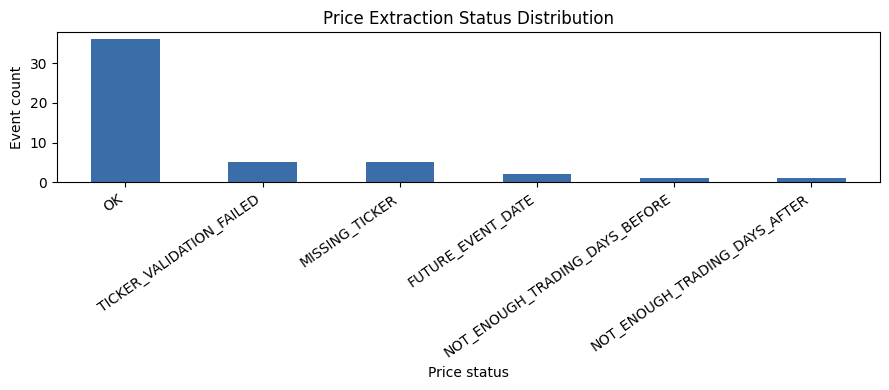

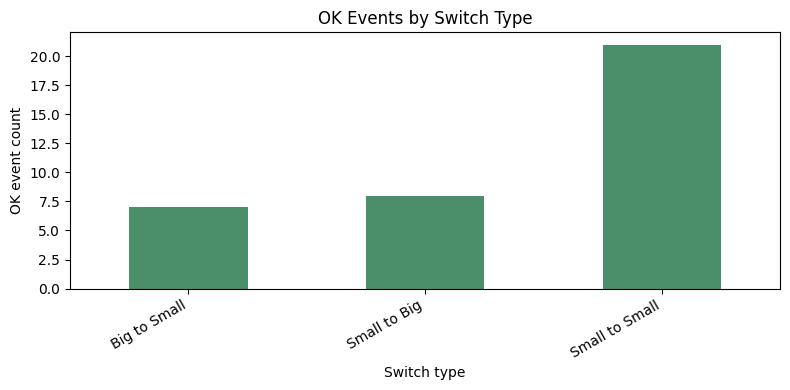

In [28]:
display(event_window_prices_df["price_status"].value_counts(dropna=False).rename_axis("price_status").reset_index(name="event_count"))
display(event_window_prices_df["market_price_status"].value_counts(dropna=False).rename_axis("market_price_status").reset_index(name="event_count"))
display(event_window_prices_df.loc[event_window_prices_df["price_status"].eq("OK")].head(10))
display(event_window_prices_df.loc[~event_window_prices_df["price_status"].eq("OK")].head(20))
display(security_price_validation_df)
display(price_extraction_report_df)

if MATPLOTLIB_AVAILABLE:
    ax = event_window_prices_df["price_status"].value_counts(dropna=False).plot.bar(figsize=(9, 4), color="#3B6EA8")
    ax.set_title("Price Extraction Status Distribution")
    ax.set_xlabel("Price status")
    ax.set_ylabel("Event count")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

    ok_by_switch = event_window_prices_df.loc[event_window_prices_df["price_status"].eq("OK")].groupby("switch_type").size()
    if not ok_by_switch.empty:
        ax = ok_by_switch.plot.bar(figsize=(8, 4), color="#4A8F6A")
        ax.set_title("OK Events by Switch Type")
        ax.set_xlabel("Switch type")
        ax.set_ylabel("OK event count")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

## 12. Validation Checks

Structural problems should stop the notebook. Normal data limitations, such as missing tickers or unavailable prices, remain as explicit row-level flags.

In [29]:
REQUIRED_EVENT_WINDOW_COLUMNS = [
    "event_id",
    "company_name",
    "switch_type",
    "event_date_basis",
    "event_date",
    "yahoo_ticker",
    "google_finance_symbol",
    "tase_security_id",
    "isin",
    "mapping_status",
    "mapping_confidence",
    "event_is_future",
    "price_extraction_eligibility",
    "price_status",
    "price_notes",
    "stock_t_minus_5_date",
    "stock_event_trading_date",
    "stock_t_plus_5_date",
    "stock_price_t_minus_5",
    "stock_price_event",
    "stock_price_t_plus_5",
    "stock_price_source",
    "market_index_ticker",
    "market_t_minus_5_date",
    "market_event_trading_date",
    "market_t_plus_5_date",
    "ta125_price_t_minus_5",
    "ta125_price_event",
    "ta125_price_t_plus_5",
    "market_price_source",
    "market_price_status",
    "market_price_notes",
    "stock_price_rows_available",
    "market_price_rows_available",
    "extraction_timestamp",
]

if len(event_window_prices_df) != len(events_df):
    raise ValueError(
        f"event_window_prices_v01 row count differs from input: output={len(event_window_prices_df)}, input={len(events_df)}"
    )

missing_required_columns = [column for column in REQUIRED_EVENT_WINDOW_COLUMNS if column not in event_window_prices_df.columns]
if missing_required_columns:
    raise ValueError(f"event_window_prices_v01 is missing required columns: {missing_required_columns}")

if event_window_prices_df["event_id"].nunique() != len(events_df):
    raise ValueError("Event IDs are not unique; one or more event rows may have been duplicated or lost.")

non_ok_missing_status = event_window_prices_df.loc[
    ~event_window_prices_df["price_status"].eq("OK")
    & event_window_prices_df["price_status"].isna()
]
if not non_ok_missing_status.empty:
    raise ValueError("One or more non-OK rows has a missing price_status.")

ok_rows = event_window_prices_df.loc[event_window_prices_df["price_status"].eq("OK")]
required_ok_price_columns = [
    "stock_price_t_minus_5",
    "stock_price_event",
    "stock_price_t_plus_5",
    "ta125_price_t_minus_5",
    "ta125_price_event",
    "ta125_price_t_plus_5",
]
ok_rows_missing_prices = ok_rows.loc[ok_rows[required_ok_price_columns].isna().any(axis=1)]
if not ok_rows_missing_prices.empty:
    raise ValueError("One or more OK rows is missing required stock or TA-125 prices.")

future_marked_ok = event_window_prices_df.loc[
    event_window_prices_df["event_is_future"].astype(bool) & event_window_prices_df["price_status"].eq("OK")
]
if not future_marked_ok.empty:
    raise ValueError("Future events must not be marked OK.")

missing_ticker_marked_ok = event_window_prices_df.loc[
    event_window_prices_df["yahoo_ticker"].isna() & event_window_prices_df["price_status"].eq("OK")
]
if not missing_ticker_marked_ok.empty:
    raise ValueError("Rows with missing tickers must not be marked OK.")

validation_summary = {
    "input_rows": int(len(events_df)),
    "output_rows": int(len(event_window_prices_df)),
    "required_columns_present": not missing_required_columns,
    "ok_rows": int(len(ok_rows)),
    "future_events_not_ok": bool(future_marked_ok.empty),
    "missing_ticker_rows_not_ok": bool(missing_ticker_marked_ok.empty),
}
validation_summary

{'input_rows': 50,
 'output_rows': 50,
 'required_columns_present': True,
 'ok_rows': 36,
 'future_events_not_ok': True,
 'missing_ticker_rows_not_ok': True}

## Notebook 03 Conclusions

The conclusion below is generated from the current run so it reflects the actual price-extraction status. Final return calculations are postponed to Notebook 04.

In [30]:
from IPython.display import Markdown, display

events_processed = len(event_window_prices_df)
events_ok = int(event_window_prices_df["price_status"].eq("OK").sum())
events_missing_ticker = int(event_window_prices_df["price_status"].eq("MISSING_TICKER").sum())
events_missing_price_data = int(event_window_prices_df["price_status"].isin(["MISSING_STOCK_PRICE_DATA", "MISSING_MARKET_PRICE_DATA", "TICKER_VALIDATION_FAILED"]).sum())
events_future = int(event_window_prices_df["price_status"].eq("FUTURE_EVENT_DATE").sum())
ta125_success = market_index_status == "OK"

saved_files = [
    event_window_prices_csv_path,
    event_window_prices_xlsx_path,
    security_validation_csv_path,
    security_validation_xlsx_path,
    report_csv_path,
    report_json_path,
    errors_csv_path,
]
saved_files_text = "\n".join(f"- `{path.relative_to(PROJECT_ROOT)}`" for path in saved_files)

conclusion = f"""
### Notebook 03 Conclusions

- Events processed: **{events_processed}**.
- Events reaching `OK` price status: **{events_ok}**.
- Events failed due to missing tickers: **{events_missing_ticker}**.
- Events failed due to missing or unavailable price data: **{events_missing_price_data}**.
- Future events skipped: **{events_future}**.
- TA-125 successfully fetched: **{ta125_success}**.

Saved files:
{saved_files_text}

Final return calculations are postponed to Notebook 04 because this notebook only prepares event-window price observations. Notebook 04 will use these price windows to compute stock returns, market returns, and market-adjusted returns.

This notebook supports the final Streamlit dashboard by creating a dashboard-ready price layer with transparent row-level status flags. Missing tickers, future events, missing price data, and market-index limitations remain visible so the dashboard can communicate data reliability clearly.
"""

display(Markdown(conclusion))


### Notebook 03 Conclusions

- Events processed: **50**.
- Events reaching `OK` price status: **36**.
- Events failed due to missing tickers: **5**.
- Events failed due to missing or unavailable price data: **5**.
- Future events skipped: **2**.
- TA-125 successfully fetched: **True**.

Saved files:
- `data\interim\event_window_prices_v01.csv`
- `data\interim\event_window_prices_v01.xlsx`
- `data\interim\security_price_validation_v01.csv`
- `data\interim\security_price_validation_v01.xlsx`
- `data\output\price_extraction_report_v01.csv`
- `data\output\price_extraction_report_v01.json`
- `data\output\price_extraction_errors_v01.csv`

Final return calculations are postponed to Notebook 04 because this notebook only prepares event-window price observations. Notebook 04 will use these price windows to compute stock returns, market returns, and market-adjusted returns.

This notebook supports the final Streamlit dashboard by creating a dashboard-ready price layer with transparent row-level status flags. Missing tickers, future events, missing price data, and market-index limitations remain visible so the dashboard can communicate data reliability clearly.
